# 01 Long-tailed distribution

Workflow:
1. Read filtered detections.
2. Build and save a category-level intermediate summary (one category per row).
3. Read intermediate summary for all downstream analyses and figures.
4. Fit and save power-law summaries for overall and semantic-specific distributions.

Run conventions (aligned with other preprint notebooks):
- Set `CATEGORY_SET` in the setup cell to `"valid129"` (default) or `"valid85"`.
- Outputs go to `analysis/preprint-2026/main_results_valid129s_04302026/` or `analysis/preprint-2026/supplemental_results_valid85cats_04302026/`.
- Tables are saved under each run's `results/`; figures under `figures/`.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [ "DejaVu Sans", "Arial", "Liberation Sans"]

# Resolve project root from this notebook location: analysis/preprint-2026/
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
PREPRINT_DIR = PROJECT_ROOT / "analysis" / "preprint-2026"
FRAME_DATA_CSV = PROJECT_ROOT / "frame_data" / "merged_frame_detections_with_metadata_filtered-0.27.csv"
CDI_CSV = DATA_DIR / "cdi_words.csv"

# Set this once at the top of the notebook.
# Supported values: "valid129" (default) or "valid85"
CATEGORY_SET = "valid85"

CATEGORY_FILES = {
    "valid85": DATA_DIR / "included_categories_valid85.txt",
    "valid129": DATA_DIR / "included_categories_valid129.txt",
}
if CATEGORY_SET not in CATEGORY_FILES:
    raise ValueError(
        f"Unsupported CATEGORY_SET: {CATEGORY_SET!r} (expected one of {sorted(CATEGORY_FILES)})"
    )
INCLUDED_CATEGORIES_TXT = CATEGORY_FILES[CATEGORY_SET]

if CATEGORY_SET == "valid129":
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "main_results_valid129s_04302026"
else:
    OUTPUT_RUN_ROOT = PREPRINT_DIR / "supplemental_results_valid85cats_04302026"

RESULTS_DIR = OUTPUT_RUN_ROOT / "results"
FIGURES_DIR = OUTPUT_RUN_ROOT / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_TOKEN = "0.27"
FILE_SUFFIX = f"filtered-{THRESHOLD_TOKEN}_{CATEGORY_SET}"
OUTPUT_INTERMEDIATE = RESULTS_DIR / f"long_tailed_dist_prop_included_categories_{FILE_SUFFIX}.csv"

print(f"[01_long_tailed_distribution] CATEGORY_SET={CATEGORY_SET!r}")
print(f"Included categories txt: {INCLUDED_CATEGORIES_TXT}")
print(f"Run root: {OUTPUT_RUN_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

# Color palette aligned with ccn-2025/long_tailed_distribution_163cats.py
CDI_SEMANTIC_ORDER = [
    "animals", "body_parts", "clothing", "food_drink", "furniture_rooms",
    "household", "outside", "people", "toys", "vehicles", "other",
]
CDI_SEMANTIC_COLORS = {
    "animals": "#4DB8A8",
    "body_parts": "#E87A5F",
    "clothing": "#9B7EC8",
    "food_drink": "#E8A54C",
    "furniture_rooms": "#6BAB7A",
    "household": "#D97B9E",
    "outside": "#5B9BD5",
    "people": "#E8C44C",
    "toys": "#B07CC8",
    "vehicles": "#6BA3D5",
    "other": "#8B9A9E",
}


def _apply_axis_style(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", labelsize=13, width=1.2)


[01_long_tailed_distribution] CATEGORY_SET='valid85'
Included categories txt: /home/j7yang/babyview-projects/vss2026/object-detection/data/included_categories_valid85.txt
Run root: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026
Results dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results
Figures dir: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures


In [7]:
# CATEGORY_SET is configured in the setup cell above.
# No additional override cell is needed.


In [8]:
# 1) Build category-level intermediate summary from filtered detections.
#    Inclusion is defined by data/included_categories_{valid85|valid129}.txt via CATEGORY_SET.
#    Output columns: category, proportion, cdi_semantic (one row per included category).

# Read included categories list
included_categories = [
    line.strip().lower()
    for line in INCLUDED_CATEGORIES_TXT.read_text().splitlines()
    if line.strip()
]
included_set = set(included_categories)

# Read filtered detections (one row per detected object)
df_det = pd.read_csv(FRAME_DATA_CSV, usecols=["class_name"])
df_det["class_name"] = df_det["class_name"].astype(str).str.strip().str.lower()

# Keep only included categories
df_det = df_det[df_det["class_name"].isin(included_set)].copy()

# Read CDI semantic mapping (uni_lemma -> category)
df_cdi = pd.read_csv(CDI_CSV, usecols=["uni_lemma", "category"])
df_cdi["uni_lemma"] = df_cdi["uni_lemma"].astype(str).str.strip().str.lower()
df_cdi["category"] = df_cdi["category"].astype(str).str.strip().str.lower()
lemma_to_semantic = (
    df_cdi.drop_duplicates(subset=["uni_lemma"], keep="first")
    .set_index("uni_lemma")["category"]
    .to_dict()
)

# Aggregate detection counts
counts = df_det.groupby("class_name").size().to_dict()
total_detected = int(sum(counts.values()))

# One row per included category (include 0 for never-detected categories)
df_cat = pd.DataFrame({"category": included_categories})
df_cat["count_detected"] = df_cat["category"].map(lambda c: int(counts.get(c, 0)))
df_cat["proportion"] = (
    df_cat["count_detected"] / total_detected if total_detected else 0.0
)
df_cat["cdi_semantic"] = df_cat["category"].map(lambda x: lemma_to_semantic.get(x, "other"))
df_cat = df_cat.sort_values("proportion", ascending=False).reset_index(drop=True)

# Write requested intermediate file
df_cat[["category", "proportion", "cdi_semantic"]].to_csv(OUTPUT_INTERMEDIATE, index=False)

print(f"Saved intermediate file: {OUTPUT_INTERMEDIATE}")
print(f"Included categories: {len(included_categories)}")
print(f"Detected rows retained (included categories only): {total_detected}")
df_cat.head(10)


Saved intermediate file: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/long_tailed_dist_prop_included_categories_filtered-0.27_valid85.csv
Included categories: 85
Detected rows retained (included categories only): 2415043


,category,count_detected,proportion,cdi_semantic
0,chair,262155,0.108551,furniture_rooms
1,lamp,200703,0.083105,household
2,table,164742,0.068215,furniture_rooms
3,couch,162456,0.067268,furniture_rooms
4,pillow,143127,0.059265,household
5,cup,105120,0.043527,household
6,toy,103218,0.042740,toys
7,bed,85036,0.035211,furniture_rooms
8,bowl,84414,0.034953,household
9,plate,73273,0.030340,household


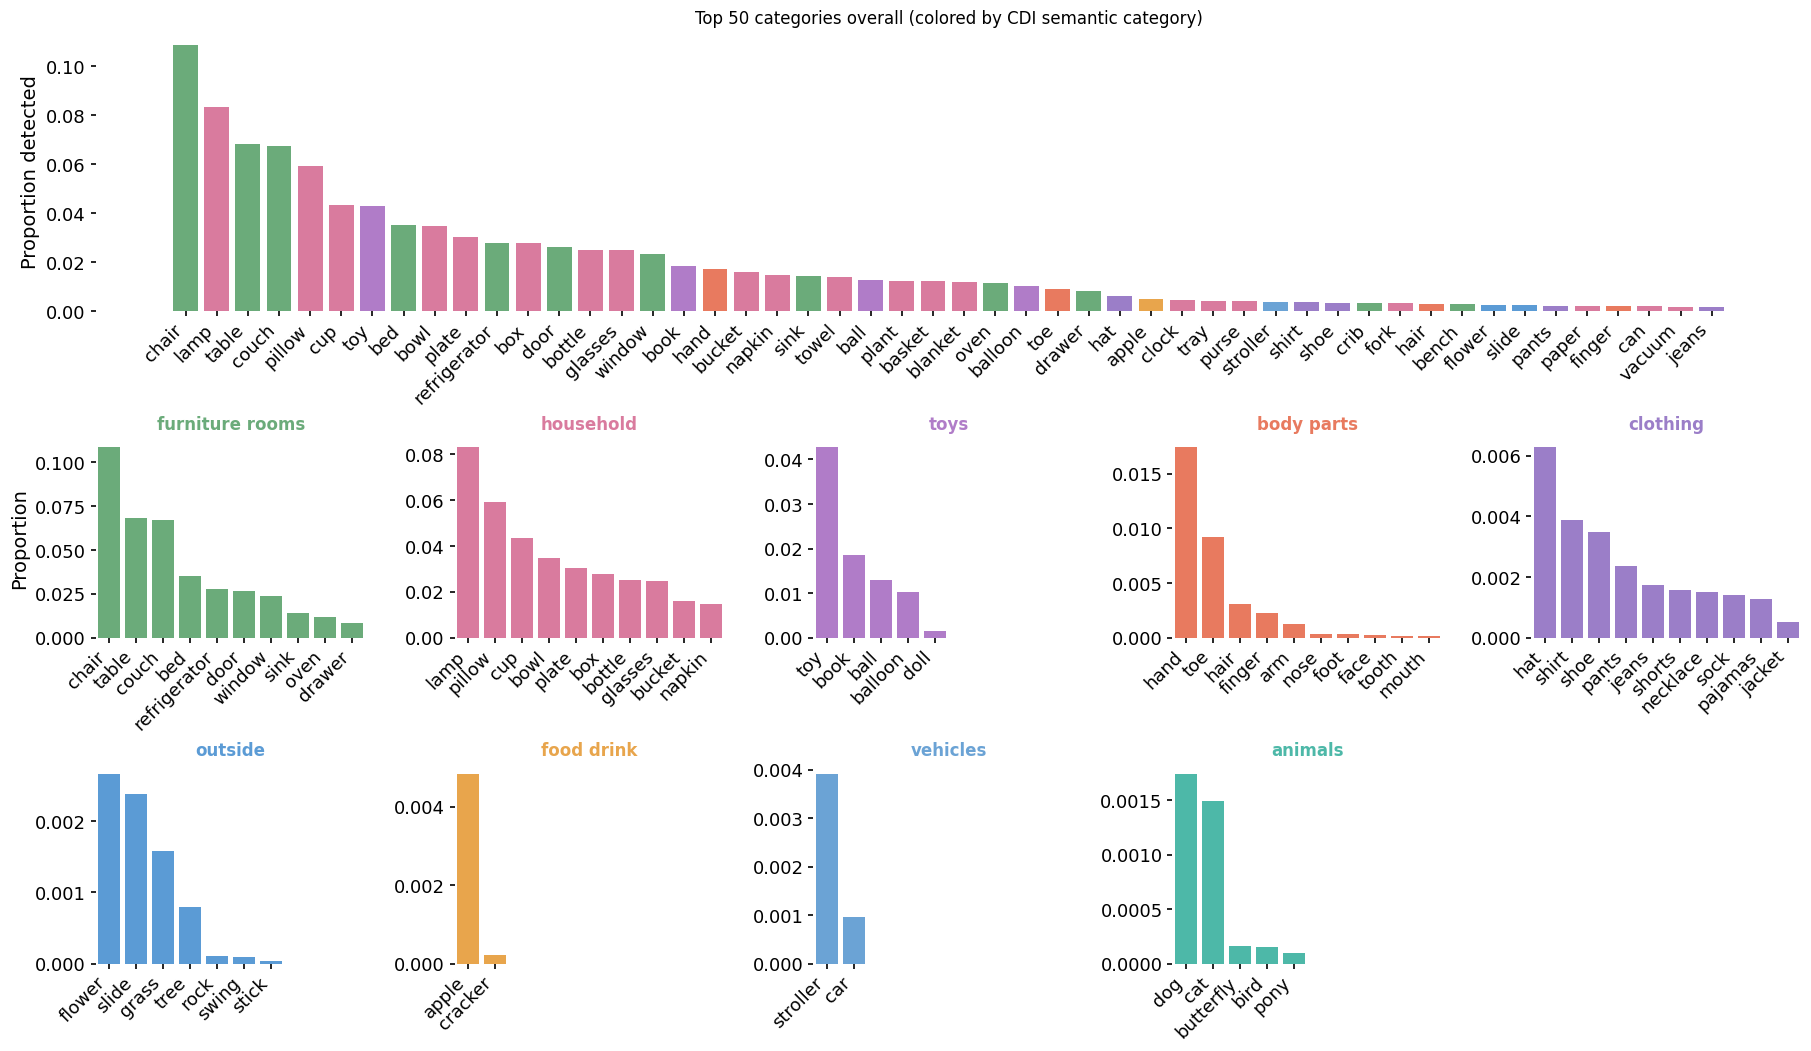

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_top50_plus_semantic_subplots_filtered-0.27_valid85.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_top50_plus_semantic_subplots_filtered-0.27_valid85.pdf


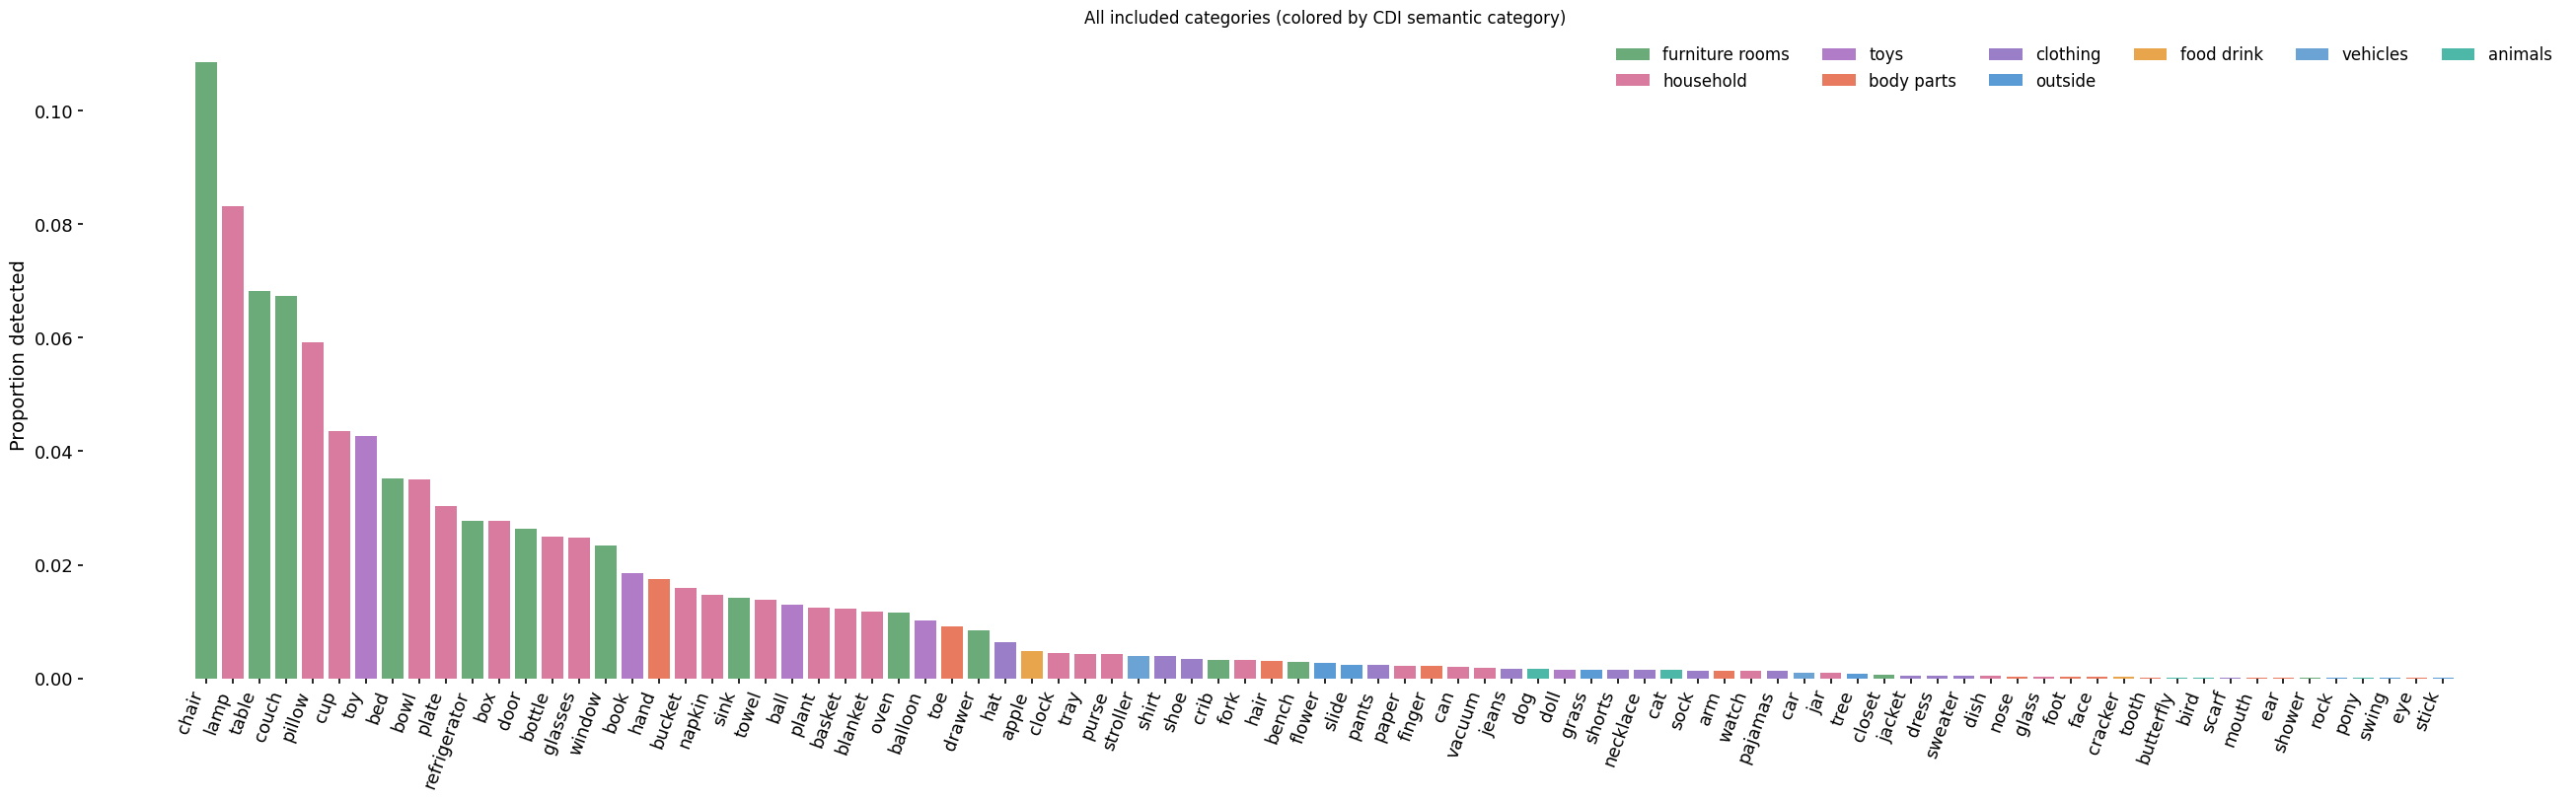

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_all_included_categories_filtered-0.27_valid85.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_all_included_categories_filtered-0.27_valid85.pdf


In [9]:
# 2) Plot long-tailed distribution:
#    - Combined panel with top-50 categories (color-coded by cdi_semantic)
#    - Subplots for each cdi semantic category (top 10 within each)
#    - Additional figure for all included categories

# Read from intermediate so downstream steps always use the same source
df_plot = pd.read_csv(OUTPUT_INTERMEDIATE)
df_plot["category"] = df_plot["category"].astype(str).str.strip().str.lower()
df_plot["cdi_semantic"] = df_plot["cdi_semantic"].astype(str).str.strip().str.lower()
df_plot = df_plot.sort_values("proportion", ascending=False).reset_index(drop=True)

# Keep only semantics that exist in this dataset, then sort subplot order by total frequency
semantic_present = [s for s in CDI_SEMANTIC_ORDER if s in set(df_plot["cdi_semantic"])]
if len(semantic_present) == 0:
    semantic_present = sorted(df_plot["cdi_semantic"].dropna().unique().tolist())

semantic_rank = (
    df_plot[df_plot["cdi_semantic"].isin(semantic_present)]
    .groupby("cdi_semantic", as_index=False)["proportion"]
    .sum()
    .sort_values("proportion", ascending=False)
)
semantic_present = semantic_rank["cdi_semantic"].tolist()

# Small ordering override requested for presentation consistency.
if "furniture_rooms" in semantic_present and "household" in semantic_present:
    semantic_present.remove("furniture_rooms")
    household_idx = semantic_present.index("household")
    semantic_present.insert(household_idx, "furniture_rooms")

# Figure layout: top row full-width + semantic subplots beneath
# Use a balanced grid for semantic panels so there is no "orphan" subplot on the last row.
n_sem = len(semantic_present)
if n_sem <= 4:
    n_cols = max(1, n_sem)
elif n_sem <= 6:
    n_cols = 3
elif n_sem <= 8:
    n_cols = 4
else:
    n_cols = 5
n_rows_sub = int(np.ceil(n_sem / n_cols)) if n_sem > 0 else 1

fig = plt.figure(figsize=(18, 4 + 3.2 * n_rows_sub), constrained_layout=True)
gs = GridSpec(1 + n_rows_sub, n_cols, figure=fig, height_ratios=[1.4] + [1] * n_rows_sub)

# Top panel: top-50 overall (no legend; semantic labels are in subplot titles)
ax_top = fig.add_subplot(gs[0, :])
top50 = df_plot.head(50).copy()
colors_50 = [CDI_SEMANTIC_COLORS.get(s, CDI_SEMANTIC_COLORS["other"]) for s in top50["cdi_semantic"]]
x50 = np.arange(len(top50))
ax_top.bar(x50, top50["proportion"], color=colors_50, edgecolor="none", width=0.8)
ax_top.set_xticks(x50)
ax_top.set_xticklabels(top50["category"], rotation=45, ha="right", fontsize=10)
ax_top.set_ylabel("Proportion detected", fontsize=14)
ax_top.set_title("Top 50 categories overall (colored by CDI semantic category)")
_apply_axis_style(ax_top)

# Semantic subplots: top 10 within each CDI semantic category
# Fix identical bar width and identical x-span across subplots for visual consistency.
for idx, sem in enumerate(semantic_present):
    row = 1 + idx // n_cols
    col = idx % n_cols
    ax = fig.add_subplot(gs[row, col])

    sub = (
        df_plot[df_plot["cdi_semantic"] == sem]
        .sort_values("proportion", ascending=False)
        .head(10)
    )

    x = np.arange(len(sub))
    color = CDI_SEMANTIC_COLORS.get(sem, CDI_SEMANTIC_COLORS["other"])
    ax.bar(x, sub["proportion"], color=color, edgecolor="none", width=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["category"], rotation=45, ha="right", fontsize=10)
    ax.set_xlim(-0.5, 9.5)  # same x-range for every subplot to keep bar size consistent
    if idx == 0:
        ax.set_ylabel("Proportion", fontsize=14)
    else:
        ax.set_ylabel("")
    ax.set_title(sem.replace("_", " "), color=color, fontsize=12, fontweight="bold")
    _apply_axis_style(ax)

# Hide any unused subplot slots
total_slots = n_rows_sub * n_cols
for j in range(n_sem, total_slots):
    row = 1 + j // n_cols
    col = j % n_cols
    ax_unused = fig.add_subplot(gs[row, col])
    ax_unused.axis("off")

out_png = FIGURES_DIR / f"long_tailed_top50_plus_semantic_subplots_{FILE_SUFFIX}.png"
out_pdf = FIGURES_DIR / f"long_tailed_top50_plus_semantic_subplots_{FILE_SUFFIX}.pdf"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_png}")
print(f"Saved figure: {out_pdf}")

# Additional figure: all included categories (single panel)
fig_all, ax_all = plt.subplots(figsize=(26, 8), constrained_layout=True)
colors_all = [CDI_SEMANTIC_COLORS.get(s, CDI_SEMANTIC_COLORS["other"]) for s in df_plot["cdi_semantic"]]
x_all = np.arange(len(df_plot))
ax_all.bar(x_all, df_plot["proportion"], color=colors_all, edgecolor="none", width=0.8)
ax_all.set_xticks(x_all)
ax_all.set_xticklabels(df_plot["category"], rotation=70, ha="right", fontsize=10)
ax_all.set_ylabel("Proportion detected", fontsize=14)
ax_all.set_title("All included categories (colored by CDI semantic category)")
_apply_axis_style(ax_all)

legend_handles_all = [
    Patch(facecolor=CDI_SEMANTIC_COLORS[k], label=k.replace("_", " "))
    for k in semantic_present
]
ax_all.legend(
    handles=legend_handles_all,
    ncol=min(6, len(legend_handles_all)),
    frameon=False,
    fontsize=12,
    loc="upper right",
)

out_all_png = FIGURES_DIR / f"long_tailed_all_included_categories_{FILE_SUFFIX}.png"
out_all_pdf = FIGURES_DIR / f"long_tailed_all_included_categories_{FILE_SUFFIX}.pdf"
fig_all.savefig(out_all_png, dpi=150, bbox_inches="tight")
fig_all.savefig(out_all_pdf, bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_all_png}")
print(f"Saved figure: {out_all_pdf}")


Saved power-law fit summary CSV: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/long_tailed_powerlaw_fits_filtered-0.27_valid85.csv
Saved power-law fit summary TXT: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/results/long_tailed_powerlaw_fits_filtered-0.27_valid85.txt


,distribution,semantic_category,n_points,alpha,intercept_log,coef_c,r2_log,rmse_log
0,overall_included_categories,all,85,1.923157,0.775050,2.170701,0.791866,0.901916
1,semantic_animals,animals,5,1.974174,-6.023882,0.002420,0.840499,0.488840
2,semantic_body_parts,body_parts,12,2.345736,-3.413511,0.032925,0.961961,0.337556
3,semantic_clothing,clothing,13,1.228005,-4.548704,0.010581,0.790345,0.465131
4,semantic_food_drink,food_drink,2,NaN,NaN,NaN,NaN,NaN
5,semantic_furniture_rooms,furniture_rooms,14,2.000319,-0.922948,0.397346,0.661667,1.066987
6,semantic_household,household,25,1.610429,-1.153180,0.315632,0.766285,0.726997
7,semantic_outside,outside,7,2.300920,-4.959442,0.007017,0.772669,0.791289
8,semantic_toys,toys,5,1.678636,-2.897888,0.055140,0.769559,0.522134
9,semantic_vehicles,vehicles,2,NaN,NaN,NaN,NaN,NaN


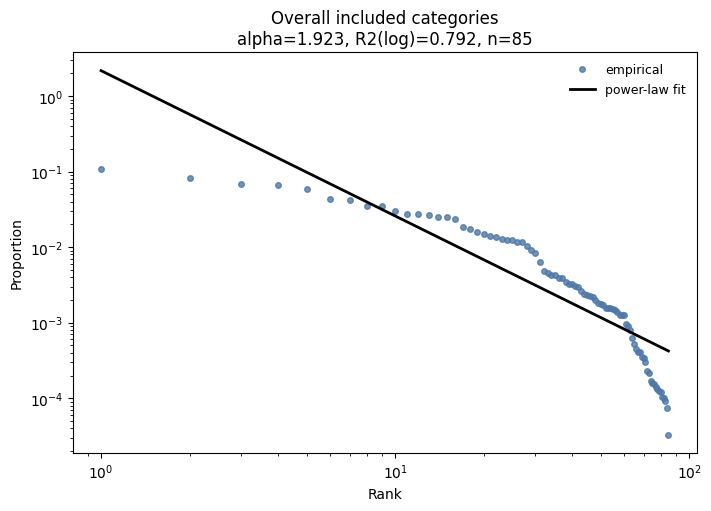

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_powerlaw_overall_filtered-0.27_valid85.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_powerlaw_overall_filtered-0.27_valid85.pdf


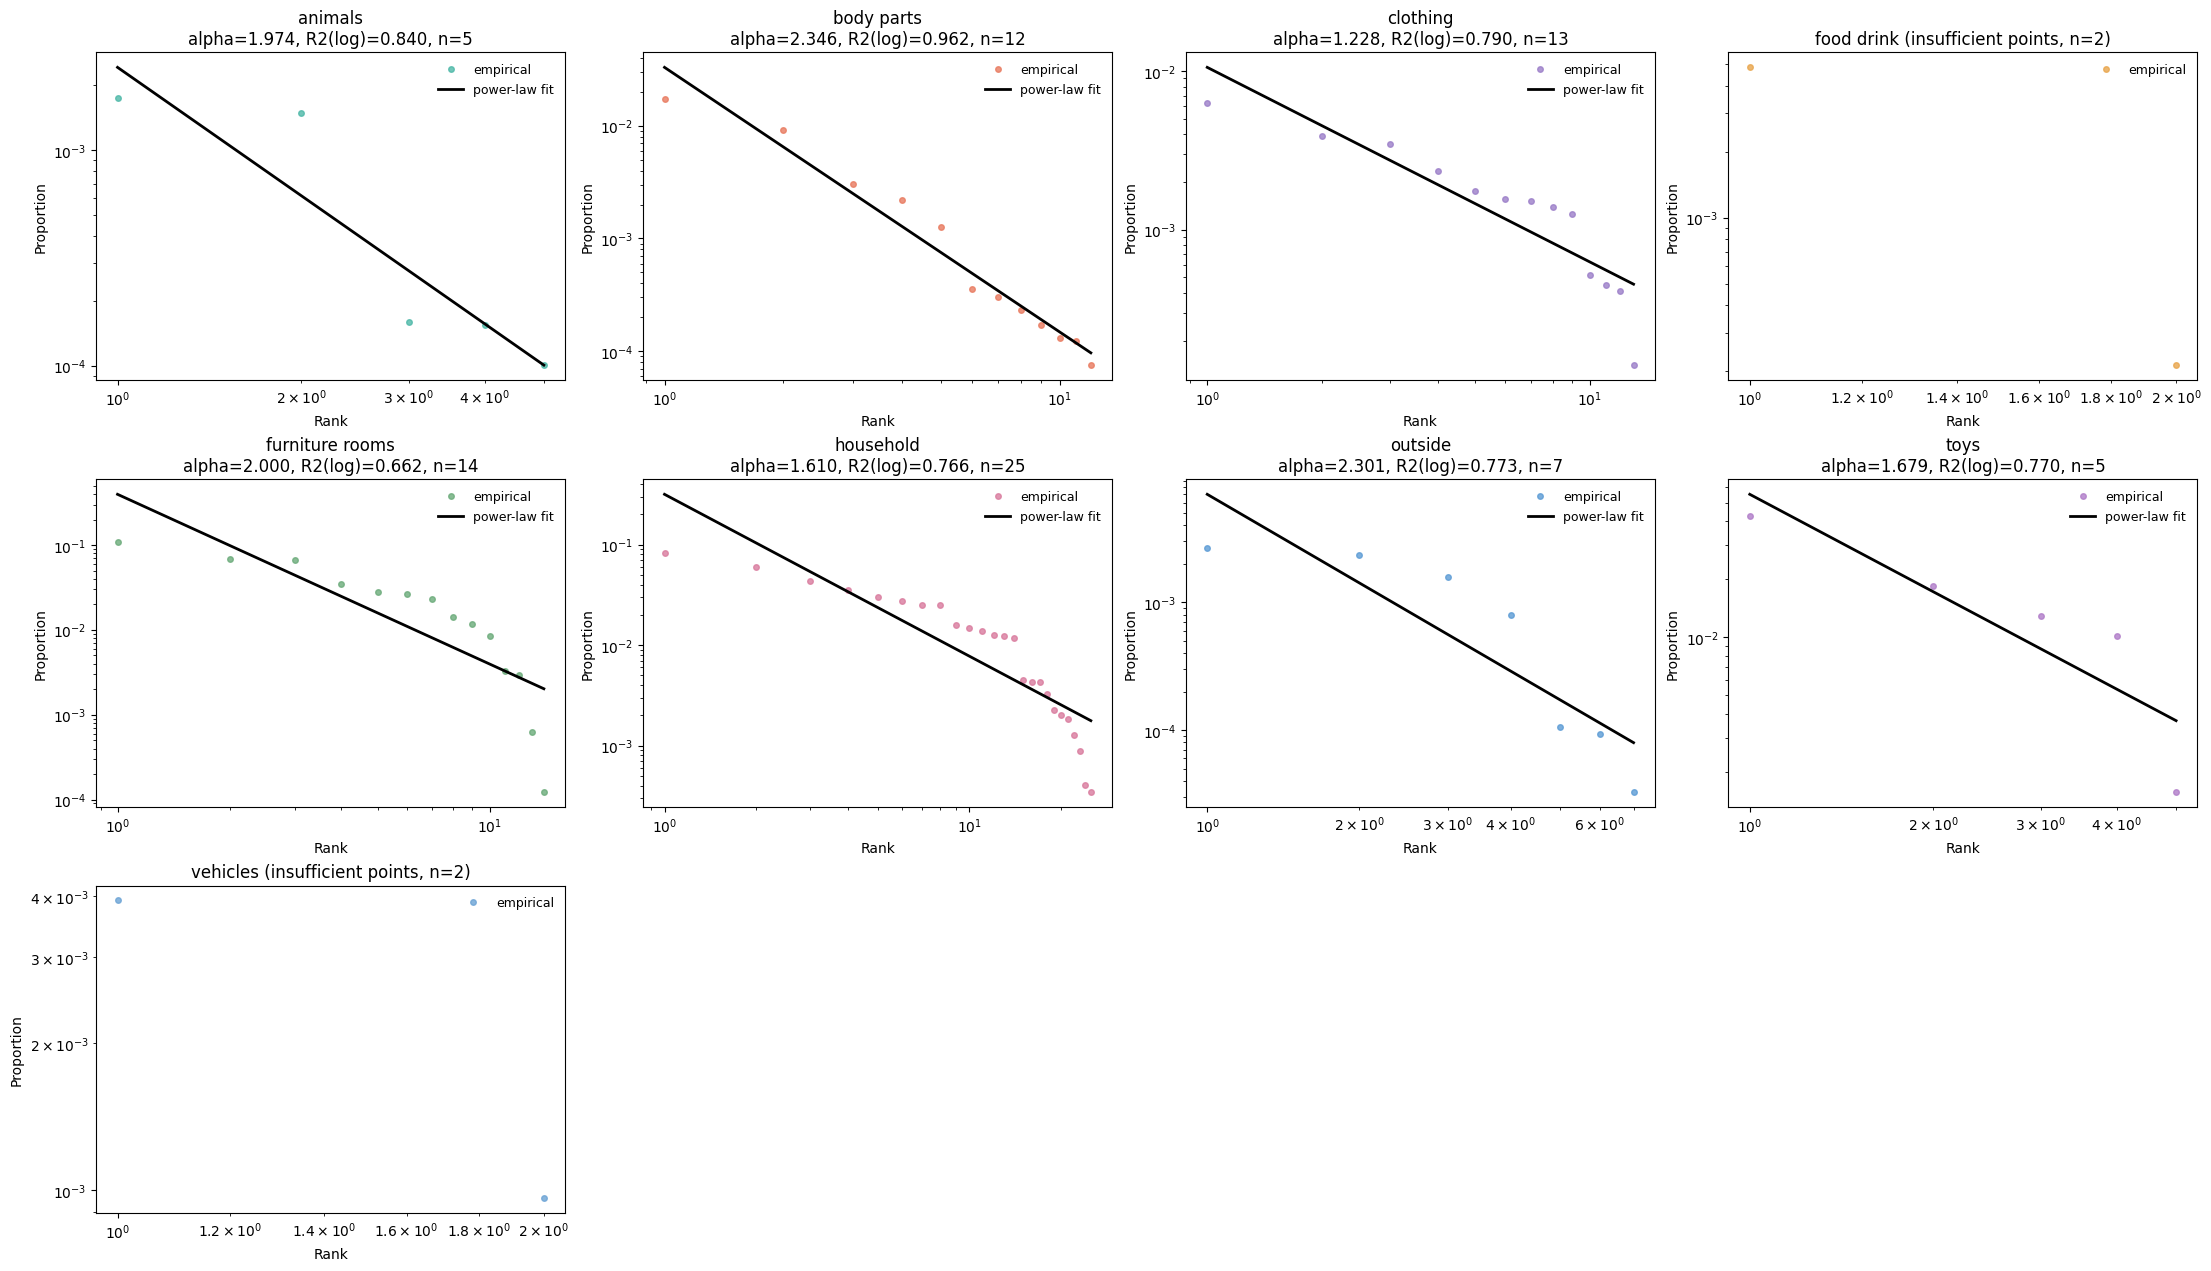

Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_powerlaw_semantic_grid_filtered-0.27_valid85.png
Saved figure: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/preprint-2026/supplemental_results_valid85cats_04302026/figures/long_tailed_powerlaw_semantic_grid_filtered-0.27_valid85.pdf


In [10]:
# 4) Power-law fitting on rank-frequency distributions
#    - Overall: all included categories
#    - Per semantic category: categories within each CDI semantic label

fit_df = pd.read_csv(OUTPUT_INTERMEDIATE)


def fit_power_law_rank(values: np.ndarray, min_points: int = 3) -> dict:
    vals = np.asarray(values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]

    vals = np.sort(vals)[::-1]
    n = vals.size
    if n < min_points:
        return {
            "n_points": int(n),
            "alpha": np.nan,
            "intercept_log": np.nan,
            "coef_c": np.nan,
            "r2_log": np.nan,
            "rmse_log": np.nan,
        }

    ranks = np.arange(1, n + 1, dtype=np.float64)
    x = np.log(ranks)
    y = np.log(vals)

    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept

    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean((y - y_hat) ** 2)))

    return {
        "n_points": int(n),
        # y = log(C) - alpha * log(rank) => slope = -alpha
        "alpha": float(-slope),
        "intercept_log": float(intercept),
        "coef_c": float(np.exp(intercept)),
        "r2_log": float(r2),
        "rmse_log": rmse,
    }


# Build fit summary table
rows = []

# Overall distribution
overall_vals = (
    fit_df["proportion"]
    .astype(float)
    .sort_values(ascending=False)
    .to_numpy()
)
overall_fit = fit_power_law_rank(overall_vals)
rows.append(
    {
        "distribution": "overall_included_categories",
        "semantic_category": "all",
        **overall_fit,
    }
)

# Semantic-specific distributions
semantic_order_for_fit = [s for s in CDI_SEMANTIC_ORDER if s in set(fit_df["cdi_semantic"].astype(str))]
for sem in semantic_order_for_fit:
    vals = (
        fit_df.loc[fit_df["cdi_semantic"] == sem, "proportion"]
        .astype(float)
        .sort_values(ascending=False)
        .to_numpy()
    )
    sem_fit = fit_power_law_rank(vals)
    rows.append(
        {
            "distribution": f"semantic_{sem}",
            "semantic_category": sem,
            **sem_fit,
        }
    )

powerlaw_summary_df = pd.DataFrame(rows)

out_fit_csv = RESULTS_DIR / f"long_tailed_powerlaw_fits_{FILE_SUFFIX}.csv"
out_fit_txt = RESULTS_DIR / f"long_tailed_powerlaw_fits_{FILE_SUFFIX}.txt"
powerlaw_summary_df.to_csv(out_fit_csv, index=False)
with open(out_fit_txt, "w", encoding="utf-8") as f:
    f.write(powerlaw_summary_df.to_string(index=False))

print(f"Saved power-law fit summary CSV: {out_fit_csv}")
print(f"Saved power-law fit summary TXT: {out_fit_txt}")
display(powerlaw_summary_df)


# Save fit figures (log-log empirical vs fitted)
def _plot_empirical_and_fit(ax, values: np.ndarray, title: str, color: str = "#4C78A8"):
    vals = np.asarray(values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    vals = np.sort(vals)[::-1]

    n = vals.size
    if n == 0:
        ax.set_title(f"{title} (no data)")
        ax.axis("off")
        return

    ranks = np.arange(1, n + 1, dtype=np.float64)
    fit = fit_power_law_rank(vals)

    ax.plot(ranks, vals, "o", ms=4, alpha=0.8, color=color, label="empirical")

    if np.isfinite(fit["alpha"]) and np.isfinite(fit["coef_c"]):
        fit_curve = fit["coef_c"] * (ranks ** (-fit["alpha"]))
        ax.plot(ranks, fit_curve, "-", lw=2, color="black", label="power-law fit")
        ax.set_title(f"{title}\nalpha={fit['alpha']:.3f}, R2(log)={fit['r2_log']:.3f}, n={fit['n_points']}")
    else:
        ax.set_title(f"{title} (insufficient points, n={fit['n_points']})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Proportion")
    ax.grid(False)
    ax.legend(frameon=False, fontsize=9)


# Overall figure
fig_overall, ax_overall = plt.subplots(figsize=(7, 5), constrained_layout=True)
_plot_empirical_and_fit(
    ax_overall,
    overall_vals,
    "Overall included categories",
    color="#4C78A8",
)
out_overall_png = FIGURES_DIR / f"long_tailed_powerlaw_overall_{FILE_SUFFIX}.png"
out_overall_pdf = FIGURES_DIR / f"long_tailed_powerlaw_overall_{FILE_SUFFIX}.pdf"
fig_overall.savefig(out_overall_png, dpi=150, bbox_inches="tight")
fig_overall.savefig(out_overall_pdf, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_overall_png}")
print(f"Saved figure: {out_overall_pdf}")


# Semantic-category grid figure
n_sem = len(semantic_order_for_fit)
if n_sem > 0:
    n_cols = 4 if n_sem >= 8 else 3
    n_rows = int(np.ceil(n_sem / n_cols))
    fig_sem, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.5 * n_cols, 4.2 * n_rows),
        constrained_layout=True,
    )
    axes = np.array(axes).reshape(-1)

    for i, sem in enumerate(semantic_order_for_fit):
        sem_vals = (
            fit_df.loc[fit_df["cdi_semantic"] == sem, "proportion"]
            .astype(float)
            .sort_values(ascending=False)
            .to_numpy()
        )
        color = CDI_SEMANTIC_COLORS.get(sem, "#4C78A8")
        _plot_empirical_and_fit(axes[i], sem_vals, sem.replace("_", " "), color=color)

    for j in range(n_sem, len(axes)):
        axes[j].axis("off")

    out_sem_png = FIGURES_DIR / f"long_tailed_powerlaw_semantic_grid_{FILE_SUFFIX}.png"
    out_sem_pdf = FIGURES_DIR / f"long_tailed_powerlaw_semantic_grid_{FILE_SUFFIX}.pdf"
    fig_sem.savefig(out_sem_png, dpi=150, bbox_inches="tight")
    fig_sem.savefig(out_sem_pdf, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {out_sem_png}")
    print(f"Saved figure: {out_sem_pdf}")